<a href="https://colab.research.google.com/github/yuliyaosipava/CoefficientDivergencii/blob/main/Divergen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving formatted_data (12).xlsx to formatted_data (12) (1).xlsx


In [ ]:
import pandas as pd
import numpy as np

# загрузка данных
df = pd.read_excel('formatted_data (12).xlsx')

In [ ]:
# логарифм показателя
df['ln_grp_pc'] = np.log(df['grp_pc'])

# функция для σ-дивергенции
def sigma_divergence(x):
    return np.sqrt(np.mean((x - np.mean(x))**2))

# расчет σ по каждому году
sigma = df.groupby('year')['ln_grp_pc'].apply(sigma_divergence)

sigma = sigma.reset_index()
sigma.columns = ['year', 'sigma']

print(sigma)

In [ ]:
indicators = df.columns.drop(['Region','Year'])

In [ ]:
def sigma_divergence(x):
    x = x[x > 0]   # убираем нули (важно для логарифма!)
    return np.sqrt(np.mean((np.log(x) - np.mean(np.log(x)))**2))

In [ ]:
sigma_results = {}

for var in indicators:
    sigma = df.groupby('Year')[var].apply(sigma_divergence)
    sigma_results[var] = sigma

sigma_df = pd.DataFrame(sigma_results)
sigma_df = sigma_df.reset_index()

print(sigma_df)

   Year   Dokhody   Eksport    Import  InvNADUshu  Proizvna1zan  PromNaDushu  \
0  2020  0.199519  0.391381  0.572297    0.285486      0.173603     0.197477   
1  2021  0.201942  0.395618  0.593489    0.242558      0.209230     0.272191   
2  2022  0.193042  0.267613  0.548548    0.229084      0.179807     0.224077   
3  2023  0.176542  0.412110  0.628148    0.240599      0.182007     0.247567   
4  2024  0.175769  0.352979  0.624529    0.231558      0.187019     0.219654   

   VRPnaDushu  ZAnNa1000  
0    0.245236   0.076089  
1    0.276043   0.074643  
2    0.243070   1.041880  
3    0.243743   0.068139  
4    0.253747   0.070517  


In [ ]:
# Сохраняем файл
sigma_df.to_excel('sigma_divergence_results.xlsx', index=False)

# Скачиваем на компьютер
from google.colab import files
files.download('sigma_divergence_results.xlsx')

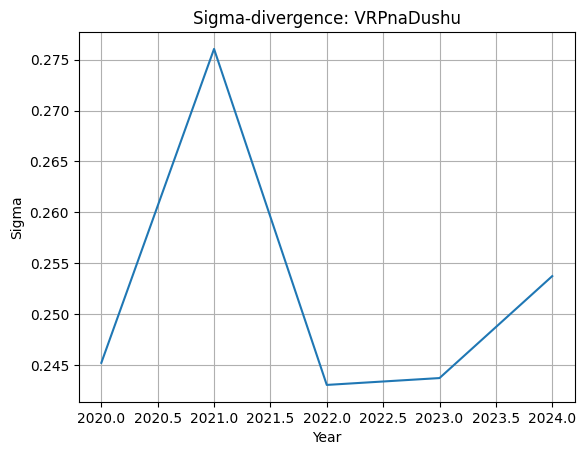

In [ ]:
import matplotlib.pyplot as plt

plt.plot(sigma_df['Year'], sigma_df['VRPnaDushu'])
plt.title('Sigma-divergence: VRPnaDushu')
plt.xlabel('Year')
plt.ylabel('Sigma')
plt.grid(True)
plt.show()

МНОГОМЕРНАЯ σ-ДИВЕРГЕНЦИЯ

In [ ]:
# загрузка
df = pd.read_excel('formatted_data (12).xlsx')

# выбираем показатели
indicators = df.columns.drop(['Region','Year'])

# функция многомерной σ
def multivariate_sigma(group):
    X = group[indicators]

    # логарифмируем (если показатели положительные)
    X = np.log(X)

    # стандартизация
    X_std = (X - X.mean()) / X.std()

    # центр масс
    centroid = X_std.mean()

    # расстояние до центра
    distances = np.sqrt(((X_std - centroid)**2).sum(axis=1))

    return distances.std()

# расчет по годам
multi_sigma = df.groupby('Year').apply(multivariate_sigma)

multi_sigma = multi_sigma.reset_index()
multi_sigma.columns = ['Year','Multivariate_sigma']

multi_sigma

/tmp/ipython-input-2251541347.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  multi_sigma = df.groupby('Year').apply(multivariate_sigma)


,Year,Multivariate_sigma
0,2020,1.258595
1,2021,1.090133
2,2022,1.113008
3,2023,0.967272
4,2024,1.043123


**ИНДЕКС ТЕЙЛА**

In [ ]:
def theil_index(x):
    x = x[x > 0]
    mean_x = np.mean(x)
    ratios = x / mean_x
    return np.mean(ratios * np.log(ratios))

theil_results = {}

for var in indicators:
    theil = df.groupby('Year')[var].apply(theil_index)
    theil_results[var] = theil

theil_df = pd.DataFrame(theil_results).reset_index()

theil_df

,Year,Dokhody,Eksport,Import,InvNADUshu,Proizvna1zan,PromNaDushu,VRPnaDushu,ZAnNa1000
0,2020,0.024943,0.080265,0.182085,0.046045,0.016358,0.019140,0.034982,0.003123
1,2021,0.025608,0.081221,0.165577,0.033117,0.022830,0.035838,0.042065,0.002997
2,2022,0.023176,0.038702,0.153629,0.028399,0.016960,0.024697,0.032483,0.121087
3,2023,0.018901,0.087924,0.195641,0.032787,0.017167,0.031203,0.032233,0.002472
4,2024,0.018664,0.064094,0.198051,0.031576,0.018284,0.024570,0.035290,0.002643
